In [191]:
class Bhai_Ka_Logistic_Regression_perceptron_trick_wala:

    def __init__(self,epoch = 1000,lr = 0.01):
        self.epoch = epoch
        self.weights = None
        self.lr = lr
        self.intercept = None
        self.coeff = None
        
    def weight_initilization(self,X):
        self.weights = np.ones(X.shape[1])

    def step_fun(self,z):
        return 1 if z>0 else 0
    
    def fit(self,X,y):
        X_new = np.insert(X,0,1,axis=1)
        self.weight_initilization(X_new)
        
        for i in range(self.epoch):
            j = np.random.randint(0,X_new.shape[0])
            y_hat = self.step_fun(np.dot(X_new[j],self.weights))
            self.weights = self.weights + self.lr*(y[j]-y_hat)*X_new[j]

        self.intercept = self.weights[0]
        self.coeff = self.weights[1:]

In [193]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [195]:
import matplotlib.pyplot as plt

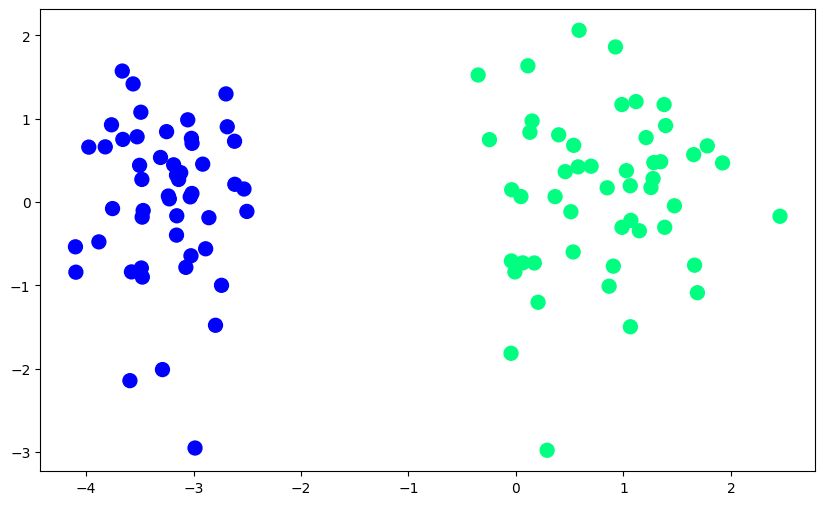

In [197]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [198]:
model = Bhai_Ka_Logistic_Regression_perceptron_trick_wala(epoch=1000)
model.fit(X,y)


In [199]:
coeff = model.coeff
intercept = model.intercept
print(coeff)
print(intercept)

[1.02824681 0.52676717]
1.1900000000000002


In [203]:
m = -(coeff[0]/coeff[1])
b = -(intercept/coeff[1])

In [205]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

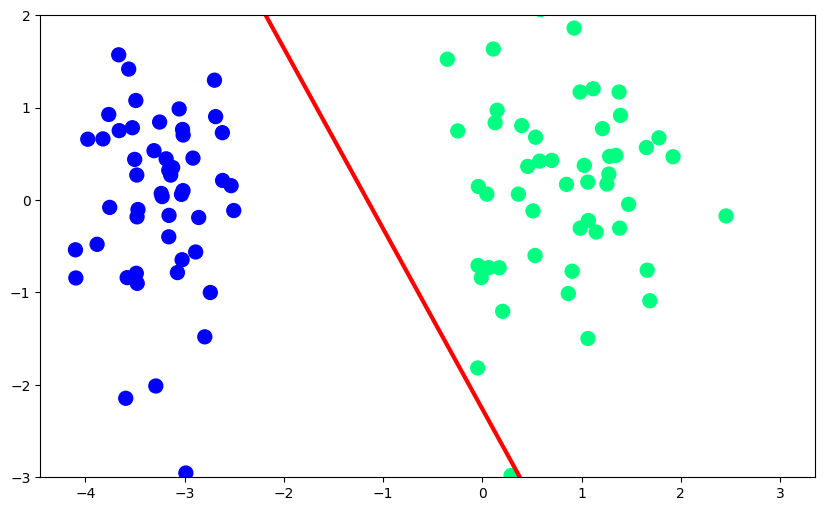

In [207]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [209]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [211]:
m_sklearn = -(lor.coef_[0][0] / lor.coef_[0][1])
b_sklearn = -(lor.intercept_ / lor.coef_[0][1])

x_input1 = np.linspace(-3, 3, 100)
y_input1 = m_sklearn * x_input1 + b_sklearn  

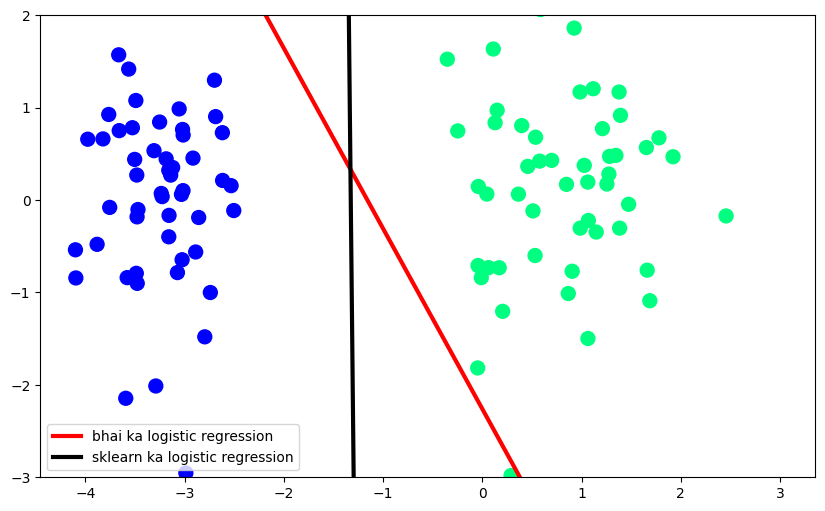

In [213]:
# %matplotlib inline

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3,label = 'bhai ka logistic regression')
plt.plot(x_input1,y_input1,color='black',linewidth=3,label = 'sklearn ka logistic regression')
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.legend()
plt.ylim(-3,2)
plt.show()